# Exercises on Part-1

This exercises follow the Sionna tutorial [Part-1](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Sionna_tutorial_part1.html).

First two exercises are taken from the tutorial, the other ones are written by Claude AI.

## Tasks on the tutorial

### 1. Pipeline for 16-QAM 

Do the same pipeline where the first example shows how to transmit QAM symbols over an AWGN channel.

Change the modulation to 16-QAM and talk about what changed.

In [1]:
"""

Before solving this we should remember the pipeline shown in the tutorial.

Necessarily;

                    QAM Constellation
      ^------------^---------^---------------^
      |            |         |               |
BinarySource -> Mapper -> AWGN Channel -> Demapper -> ... 


"""

from sionna.phy.mapping import Mapper, Demapper
from sionna.phy.mapping import Constellation, BinarySource

from sionna.phy.utils import ebnodb2no

from sionna.phy.channel import AWGN

NUM_BITS_PER_SYMBOL = 4
BLOCK_LENGTH = 128
BATCH_SIZE = 1024
EBNO_DB = 10
CODE_RATE = 1

source = BinarySource()

constellation = Constellation("qam", NUM_BITS_PER_SYMBOL)

mapper = Mapper(constellation=constellation)
demapper = Demapper("app", constellation=constellation)

awgn = AWGN()

bits = source( [BATCH_SIZE, BLOCK_LENGTH ] )

x = mapper(bits)

no = ebnodb2no( EBNO_DB, NUM_BITS_PER_SYMBOL, CODE_RATE )

y = awgn(x, no)

llr = demapper(y, no)


### 2. Demapping deeper look 

Compare the LLR distribution for “app” demapping with “maxlog” demapping. The [Bit-Interleaved Coded Modulation](https://nvlabs.github.io/sionna/phy/tutorials/notebooks/Bit_Interleaved_Coded_Modulation.html) example notebook can be helpful for this task.

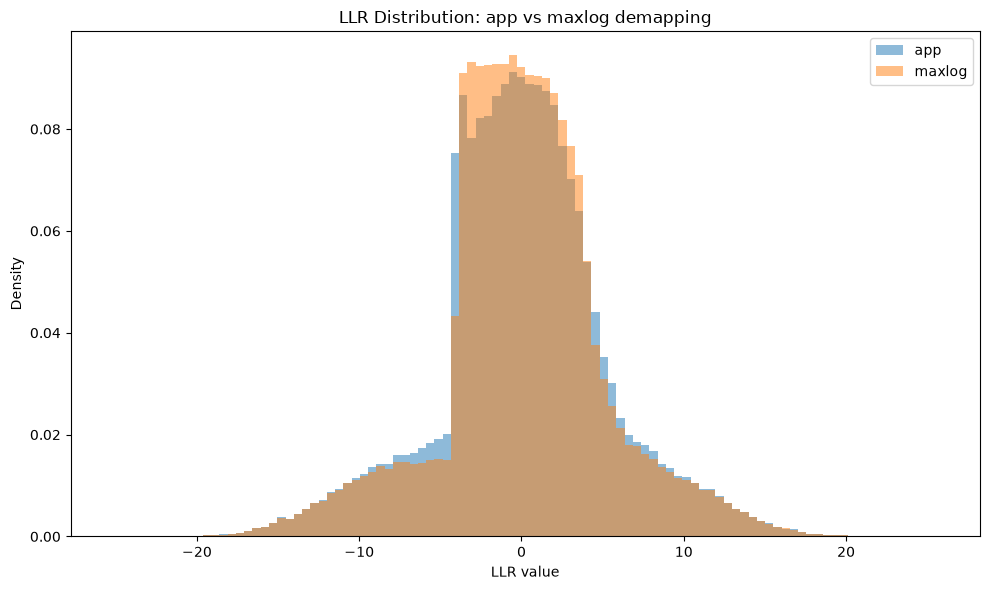

Max abs diff: 0.6928253
Mean abs diff: 0.13009286


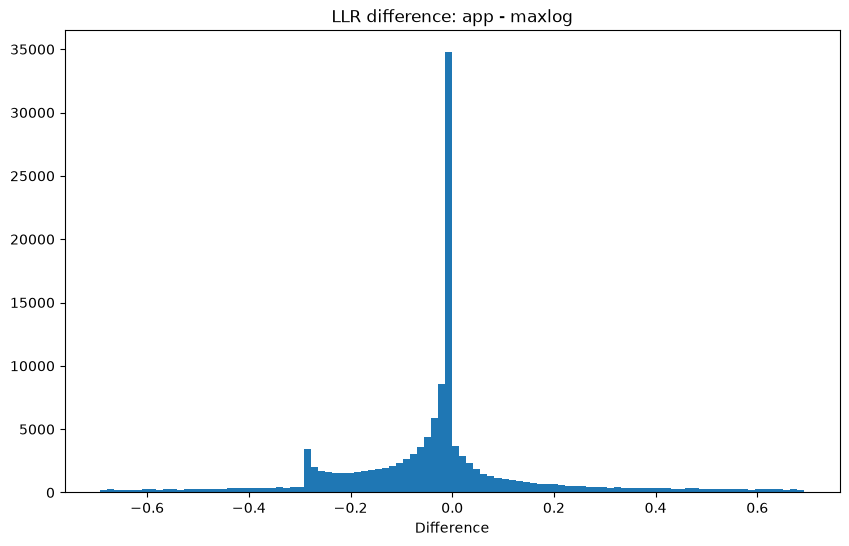

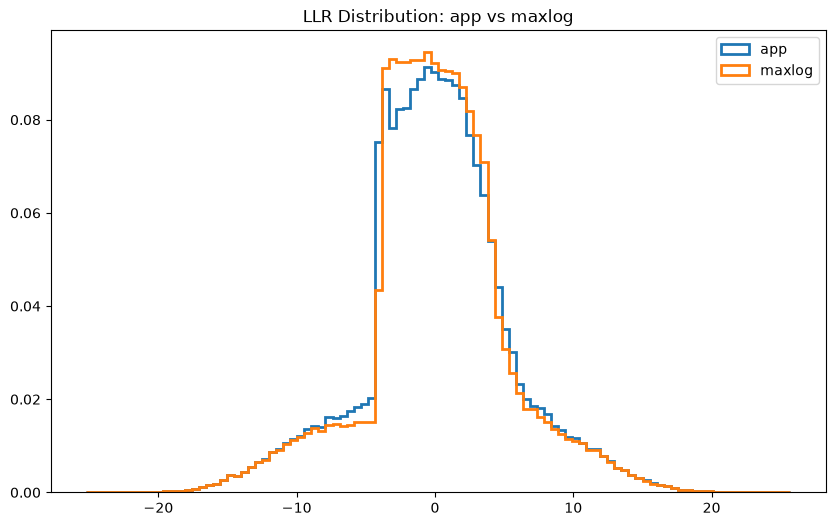

In [15]:
from sionna.phy.mapping import Mapper, Demapper
from sionna.phy.mapping import Constellation, BinarySource

from sionna.phy.utils import ebnodb2no

from sionna.phy.channel import AWGN



import matplotlib.pyplot as plt
import numpy as np


NUM_BITS_PER_SYMBOL = 4
BLOCK_LENGTH = 128
BATCH_SIZE = 1024
EBNO_DB = 1
CODE_RATE = 1

source = BinarySource()

constellation = Constellation("qam", NUM_BITS_PER_SYMBOL)

mapper = Mapper(constellation=constellation)

demapper1 = Demapper("app", constellation=constellation)
demapper2 = Demapper("maxlog", constellation=constellation)

awgn = AWGN()

bits = source( [BATCH_SIZE, BLOCK_LENGTH ] )

x = mapper(bits)

no = ebnodb2no( EBNO_DB, NUM_BITS_PER_SYMBOL, CODE_RATE )

y = awgn(x, no)

llr1 = demapper1(y, no)
llr2 = demapper2(y, no)

plt.figure(figsize=(10, 6))
plt.hist(llr1.cpu().numpy().flatten(), bins=100, alpha=0.5, label="app", density=True)
plt.hist(llr2.cpu().numpy().flatten(), bins=100, alpha=0.5, label="maxlog", density=True)
plt.xlabel("LLR value")
plt.ylabel("Density")
plt.title("LLR Distribution: app vs maxlog demapping")
plt.legend()
plt.tight_layout()
plt.show()

if llr1.equal(llr2):
    print("PANDA")


diff = (llr1 - llr2).cpu().numpy().flatten()
print("Max abs diff:", np.abs(diff).max())
print("Mean abs diff:", np.abs(diff).mean())

plt.figure(figsize=(10,6))
plt.hist(diff, bins=100)
plt.title("LLR difference: app - maxlog")
plt.xlabel("Difference")
plt.show()

plt.figure(figsize=(10,6))
plt.hist(llr1.cpu().numpy().flatten(), bins=100, histtype='step', linewidth=2, label="app", density=True)
plt.hist(llr2.cpu().numpy().flatten(), bins=100, histtype='step', linewidth=2, label="maxlog", density=True)
plt.legend()
plt.title("LLR Distribution: app vs maxlog")
plt.show()

!!! Dropping EBNO_DB down to 0, -3 reveals the app/maxlog difference histogram spread out much more.

This shows how much the approximation coming from max-log costs.

### 3. Multi-modulation Block


Extend UncodedSystemAWGN into MultiModAWGN, where __init__ takes a list of (constellation_type, num_bits_per_symbol) pairs instead of one fixed pair, and builds a separate Constellation/Mapper/Demapper for each. call(batch_size, ebno_db, mod_index) should pick which modulation to run based on mod_index. This is the direct precursor to looping over modulation types when generating your dataset — same problem, smaller scope.


In [ ]:
from sionna.phy.mapping import Mapper, Demapper
from sionna.phy.mapping import Constellation, BinarySource

from sionna.phy.utils import ebnodb2no

from sionna.phy.channel import AWGN

from sionna.phy.block import Block

import matplotlib.pyplot as plt
import numpy as np

class MultiModAWGN(Block):


    def __init__(
            self,
            constellation_type: list,
            num_bits_per_symbol: list,
            block_length = 1024,
            ):

        self.constellation_type = constellation_type
        self.num_bits_per_symbol = num_bits_per_symbol

        self.block_length = block_length

        self.mapper = Mapper()
        self.demapper = Demapper()

        self.source = BinarySource()


    def call(self, batch_size, ebno_db, mod_index):

        self.CONSTELLATION = self.constellation_type[mod_index]
        self.CONSTELLATION = self.num_bits_per_symbol[mod_index]

        self.mapper = Mapper(self.constellation_type[mod_index])
        self.demapper = Demapper(self.)




### 4. Add a modulation label to the output

Modify the class from #1 so call() returns (x, y, label) instead of (bits, llr) — where label is an integer or string identifying which modulation produced that batch (e.g. 0 for QPSK, 1 for 16-QAM). This is literally the (sample, label) structure your ML dataset needs, just not saved to disk yet.

### 5. SNR as a per-sample varying value, not a fixed scalar

So far ebno_db has been one fixed value per call(). Modify the class so call() accepts a range of ebno_db values (e.g. a Python list [-10, 0, 10, 20]) and loops internally, returning a batch of (x, y, label, snr) for every combination of modulation × SNR. This is the core loop structure of your actual dataset generator — you're building it now, just without the fading channel yet.

### 6. Save it

Take the output of #3 and stack it into numpy arrays, then save with np.savez (or similar) as (iq_samples, mod_labels, snr_labels). Load it back in a fresh cell and confirm the shapes and labels match what went in. This is the exact save/load pattern you'll need for the real dataset, minus fading.

### 7. Break/inspect exercise, kept from before because it matters

In your class from #1, try calling .call() directly instead of model(...). Confirm it behaves the same, and figure out why the tutorial always uses model(...) — this is exactly the AWGN.__call__ vs .call() distinction from your very first debugging session, and understanding it will save you from a confusing bug later.